In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [25]:
# 0. Common imports & device
import os, gc, math, random, time
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [27]:
# 1) LOAD & CLEAN CSV (feature: handle NaNs in egoinvolve)
CSV_PATH = "/kaggle/input/car-crash-dataset-ccd/Crash_Table.csv"
IMG_DIR = "/kaggle/input/car-crash-dataset-ccd/CrashBest/"

df = pd.read_csv(CSV_PATH)
print("Original CSV rows:", len(df))

# Drop rows without label
df = df.dropna(subset=["egoinvolve"])
# Map Yes/No to 1/0
df["egoinvolve"] = df["egoinvolve"].map({"Yes": 1, "No": 0})
df["vidname"] = df["vidname"].astype(int) 


Original CSV rows: 1500


In [29]:
# 2) PARSE IMAGE FILENAMES & GROUP BY VIDEO ID
# Filenames like: C_000071_08.jpg  -> video 71, frame 8
image_files = sorted([p for p in Path(IMG_DIR).glob("*.jpg")])
print("Total image files in CrashBest:", len(image_files))

# helper to parse
def parse_filename(fname):
    # fname stem: C_000071_08
    stem = Path(fname).stem
    parts = stem.split("_")
    # parts = [C, 000071, 08]
    vid = int(parts[1])
    frame = int(parts[2])
    return vid, frame

# group
video_frames = defaultdict(list)
for p in image_files:
    vid, frame = parse_filename(p)
    video_frames[vid].append((frame, str(p)))

# sort frames per video
for vid in list(video_frames)[:5]:
    video_frames[vid] = sorted(video_frames[vid], key=lambda x: x[0])



Total image files in CrashBest: 75000


### RGB Sequence

In [31]:
SEQ_LEN = 16       # temporal clip length (proposal used 16)
STEP = 8           
min_frames_required = SEQ_LEN

# build mapping vid -> label
label_map = dict(zip(df["vidname"].astype(int), df["egoinvolve"].astype(int)))

sequences = []  
for vid, frames in video_frames.items():
    if vid not in label_map:
        continue
    if len(frames) < min_frames_required:
        continue
    # extract only the paths ordered
    ordered_paths = [p for f,p in frames]
    # sliding windows
    for start in range(0, len(ordered_paths)-SEQ_LEN+1, STEP):
        clip = ordered_paths[start:start+SEQ_LEN]
        sequences.append((clip, label_map[vid]))

print("Total sequences built:", len(sequences))
# quick label distribution
labels = [lab for _, lab in sequences]
print("Label counts:", {0: labels.count(0), 1: labels.count(1)})


Total sequences built: 7500
Label counts: {0: 3495, 1: 4005}


### Optical Flow

In [33]:
def compute_flow_for_sequence(rgb_paths):
    # returns list of np arrays (H,W,3) representing flow in HSV->BGR as in many two-stream works
    flows = []
    prev_gray = None
    for p in rgb_paths:
        img = cv2.imread(p)  # BGR
        img = cv2.resize(img, (224,224))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        if prev_gray is None:
            # append zeros for first frame (or duplicate)
            flows.append(np.zeros_like(img))
            prev_gray = gray
            continue
        # Farneback
        flow = cv2.calcOpticalFlowFarneback(prev_gray, gray,
                                            None, 0.5, 3, 15, 3, 5, 1.2, 0)
        mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])
        hsv = np.zeros_like(img)
        hsv[...,1] = 255
        hsv[...,0] = ang * 180 / np.pi / 2
        hsv[...,2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
        bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
        flows.append(bgr)
        prev_gray = gray
    return flows


In [34]:
# Pytorch Dataset (feature: returns rgb_clip tensor and flow_clip tensor and label)
class CCDTwoStreamDataset(Dataset):
    def __init__(self, sequences, seq_len=SEQ_LEN, img_size=224, transform=None, flow_transform=None):
        self.sequences = sequences
        self.seq_len = seq_len
        self.img_size = img_size
        self.transform = transform
        self.flow_transform = flow_transform

    def __len__(self):
        return len(self.sequences)

    def load_rgb_clip(self, paths):
        clips = []
        for p in paths:
            img = cv2.imread(p)[:, :, ::-1]  # BGR->RGB
            img = cv2.resize(img, (self.img_size, self.img_size))
            clips.append(img)
        return clips

    def load_flow_clip(self, paths):
        flows = compute_flow_for_sequence(paths)
        return flows

    def preprocess_clip(self, clip_list, is_flow=False):
        # clip_list: list of HxWx3 uint8 np arrays
        tensors = []
        for img in clip_list:
            img = img.astype(np.float32) / 255.0
            if self.transform is not None and not is_flow:
                img = self.transform(img)
            elif self.flow_transform is not None and is_flow:
                img = self.flow_transform(img)
            else:
                # default: transpose to C,H,W
                img = np.transpose(img, (2,0,1))
                img = torch.from_numpy(img).float()
            tensors.append(img)
        # stack to shape (C, T, H, W) for 3D convs
        tensors = torch.stack(tensors, dim=1)
        return tensors

    def __getitem__(self, idx):
        paths, label = self.sequences[idx]
        rgb_clip = self.load_rgb_clip(paths)
        flow_clip = self.load_flow_clip(paths)

        rgb_tensor = self.preprocess_clip(rgb_clip, is_flow=False)
        flow_tensor = self.preprocess_clip(flow_clip, is_flow=True)

        return rgb_tensor, flow_tensor, torch.tensor(label, dtype=torch.long)


In [35]:
# 6) Transforms & dataset + dataloaders (feature: normalization)
# Define simple transforms (mean/std same as ImageNet)
mean = [0.485,0.456,0.406]
std = [0.229,0.224,0.225]

def np_img_to_tensor(img):
    # img is numpy H,W,3 float32 0..1
    img = (img - np.array(mean)) / np.array(std)
    img = np.transpose(img, (2,0,1))
    return torch.from_numpy(img).float()

# We'll pass transform functions to dataset
def rgb_transform(img_np):
    return np_img_to_tensor(img_np)

def flow_transform(img_np):
    # flow image is BGR-like from our function but passed in as RGB array when loaded in Dataset (we used compute_flow that returns BGR)
    # ensure it's normalized similarly
    return np_img_to_tensor(img_np)

# build dataset
random.shuffle(sequences)
split = int(0.8 * len(sequences))
train_seq = sequences[:split]
val_seq = sequences[split:split + int(0.1*len(sequences))]
test_seq = sequences[split + int(0.1*len(sequences)):]

train_ds = CCDTwoStreamDataset(train_seq, transform=rgb_transform, flow_transform=flow_transform)
val_ds   = CCDTwoStreamDataset(val_seq, transform=rgb_transform, flow_transform=flow_transform)
test_ds  = CCDTwoStreamDataset(test_seq, transform=rgb_transform, flow_transform=flow_transform)

print("Train sequences:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))


Train sequences: 6000 Val: 750 Test: 750


Device: cuda
CSV rows: 1500
Label distribution (from CSV): {1: 801, 0: 699}
Total raw files in CrashBest: 75000
Usable videos (have label & >=SEQ_LEN): 1500
Total sequences built: 7500
Unique frames to resize: 72000
Resizing done -> /kaggle/working/frames_resized
Videos with resized frames available: 1500
Optical flow cached -> /kaggle/working/flows
Sequences total: 7500 Dropped due missing files: 0 Valid sequences: 7500
Sizes (train,val,test): 5400 600 1500


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=R3D_18_Weights.KINETICS400_V1`. You can also use `weights=R3D_18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipykernel_142/1261698893.py:329: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.

Trainable params: 50408322


Train:   0%|          | 0/450 [00:00<?, ?it/s]/tmp/ipykernel_142/1261698893.py:339: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=="cuda")):
Eval:   0%|          | 0/50 [00:00<?, ?it/s]            /tmp/ipykernel_142/1261698893.py:359: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=="cuda")):


Epoch 1/8 | train_loss=0.4149 | val_loss=0.4514 | val_acc=0.8283 | time=392.9s
Saved best model.


...

Epoch 5/8 | train_loss=0.0673 | val_loss=0.3059 | val_acc=0.9217 | time=385.4s


Train:   0%|          | 0/450 [00:00<?, ?it/s]/tmp/ipykernel_142/1261698893.py:339: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=="cuda")):
Eval:   0%|          | 0/50 [00:00<?, ?it/s]            /tmp/ipykernel_142/1261698893.py:359: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=="cuda")):


Epoch 6/8 | train_loss=0.0545 | val_loss=0.3021 | val_acc=0.9150 | time=386.2s
Early stopping


Eval:   0%|          | 0/125 [00:00<?, ?it/s]/tmp/ipykernel_142/1261698893.py:359: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=="cuda")):
/tmp/ipykernel_142/1261698893.py:416: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE.type=="cuda")):


Test samples: 1500
Test Loss: 0.2535  Acc: 0.9193  Prec: 0.9198  Rec: 0.9301  F1: 0.9249

Classification Report:
               precision    recall  f1-score   support

           0     0.9188    0.9070    0.9129       699
           1     0.9198    0.9301    0.9249       801

    accuracy                         0.9193      1500
   macro avg     0.9193    0.9185    0.9189      1500
weighted avg     0.9193    0.9193    0.9193      1500


Confusion Matrix:
 [[634  65]
 [ 56 745]]


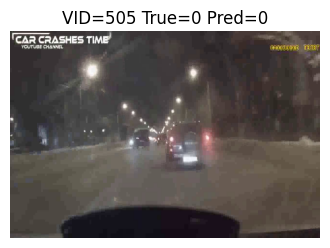

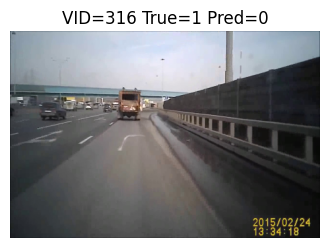

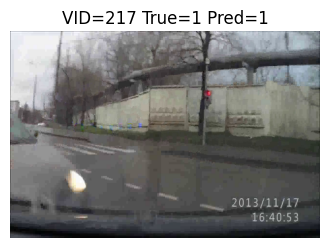

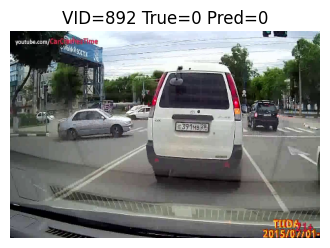

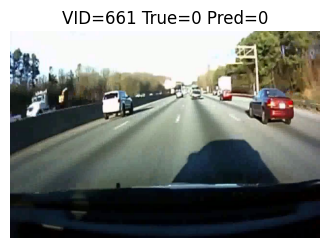

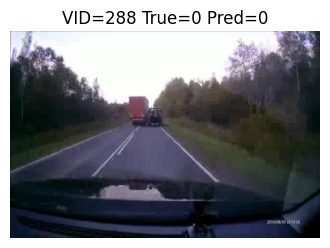

Model checkpoint saved at: /kaggle/working/two_stream_i3d_fast.pth


In [ ]:
import os, time, random
from pathlib import Path
from tqdm import tqdm
import multiprocessing as mp

import numpy as np
import pandas as pd
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision.transforms import Normalize
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

CSV_PATH = "/kaggle/input/car-crash-dataset-ccd/Crash_Table.csv"
IMG_DIR = "/kaggle/input/car-crash-dataset-ccd/CrashBest/"
RESIZED_DIR = "/kaggle/working/frames_resized"
FLOW_DIR = "/kaggle/working/flows"
SEQ_LEN = 16
STEP = 8
IMG_SIZE = 224
BATCH_SIZE = 12
NUM_WORKERS = 4
NUM_PREPROCESS_WORKERS = 4
EPOCHS = 8
LR = 1e-4
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True

df = pd.read_csv(CSV_PATH)
print("CSV rows:", len(df))
df = df.dropna(subset=["egoinvolve"])
df["egoinvolve"] = df["egoinvolve"].map({"Yes":1, "No":0})
df["vidname"] = df["vidname"].astype(int)
label_map = dict(zip(df["vidname"].astype(int), df["egoinvolve"].astype(int)))
print("Label distribution (from CSV):", pd.Series(label_map).value_counts().to_dict())

all_files = sorted([str(p) for p in Path(IMG_DIR).glob("*.jpg")])
print("Total raw files in CrashBest:", len(all_files))

def parse_vid_frame(path):
    stem = Path(path).stem
    parts = stem.split("_")
    if len(parts) < 3:
        return None, None
    try:
        return int(parts[1]), int(parts[2])
    except:
        return None, None

video_frames = {}
for p in all_files:
    vid, fno = parse_vid_frame(p)
    if vid is None:
        continue
    video_frames.setdefault(vid, []).append((fno, p))

for vid in list(video_frames.keys()):
    video_frames[vid] = [p for (_,p) in sorted(video_frames[vid], key=lambda x:x[0])]

usable_videos = [vid for vid, frames in video_frames.items() if vid in label_map and len(frames) >= SEQ_LEN]
print("Usable videos:", len(usable_videos))

# Spatio-Temporal
sequences = []
for vid in usable_videos:
    frames = video_frames[vid]
    label = int(label_map[vid])
    n = len(frames)
    for start in range(0, n - SEQ_LEN + 1, STEP):
        clip = frames[start:start+SEQ_LEN]
        if len(clip) == SEQ_LEN:
            sequences.append((clip, label, vid))
print("Total sequences built:", len(sequences))
if len(sequences) == 0:
    raise SystemExit("No sequences built.")

os.makedirs(RESIZED_DIR, exist_ok=True)
used_files = sorted({p for seq in sequences for p in seq[0]})
print("Unique frames to resize:", len(used_files))

def resize_worker(file_list):
    for src in file_list:
        dst = os.path.join(RESIZED_DIR, Path(src).name)
        if os.path.exists(dst):
            continue
        img = cv2.imread(src)
        if img is None:
            continue
        try:
            r = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            cv2.imwrite(dst, r, [int(cv2.IMWRITE_JPEG_QUALITY), 90])
        except:
            continue

chunks = []
n = max(1, NUM_PREPROCESS_WORKERS)
step = (len(used_files) + n - 1) // n
for i in range(0, len(used_files), step):
    chunks.append(used_files[i:i+step])

if NUM_PREPROCESS_WORKERS <= 1:
    resize_worker(chunks[0])
else:
    pool = mp.Pool(NUM_PREPROCESS_WORKERS)
    pool.map(resize_worker, chunks)
    pool.close(); pool.join()
print("Resizing done ->", RESIZED_DIR)

# Optical Flow Computation
os.makedirs(FLOW_DIR, exist_ok=True)

video_to_resized = {}
for vid in usable_videos:
    resized_list = [os.path.join(RESIZED_DIR, Path(p).name) for p in video_frames[vid] if os.path.exists(os.path.join(RESIZED_DIR, Path(p).name))]
    if len(resized_list) >= SEQ_LEN:
        video_to_resized[vid] = resized_list

print("Videos with resized frames:", len(video_to_resized))

def compute_flow_for_video_list(video_list):
    for resized_files in video_list:
        prev_gray = None
        for fp in resized_files:
            try:
                flow_out = os.path.join(FLOW_DIR, "flow_" + Path(fp).name)
            except Exception:
                continue
            if os.path.exists(flow_out):
                prev_gray = cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2GRAY) if os.path.exists(fp) else None
                continue
            if not os.path.exists(fp):
                prev_gray = None
                continue
            img = cv2.imread(fp)
            if img is None:
                prev_gray = None
                continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            if prev_gray is None:
                zero = np.zeros_like(img)
                cv2.imwrite(flow_out, zero, [int(cv2.IMWRITE_JPEG_QUALITY), 90])
                prev_gray = gray
                continue
            flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None,
                                                0.5, 3, 15, 3, 5, 1.2, 0)
            mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])
            hsv = np.zeros_like(img)
            hsv[...,1] = 255
            hsv[...,0] = ang * 180 / np.pi / 2
            hsv[...,2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
            bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
            cv2.imwrite(flow_out, bgr, [int(cv2.IMWRITE_JPEG_QUALITY), 90])
            prev_gray = gray

video_resized_lists = list(video_to_resized.values())
if len(video_resized_lists) == 0:
    raise SystemExit("No resized lists found.")

n = max(1, NUM_PREPROCESS_WORKERS)
step = (len(video_resized_lists) + n - 1) // n
video_chunks = [video_resized_lists[i:i+step] for i in range(0, len(video_resized_lists), step)]

if NUM_PREPROCESS_WORKERS <= 1:
    compute_flow_for_video_list(video_chunks[0])
else:
    pool = mp.Pool(NUM_PREPROCESS_WORKERS)
    pool.map(compute_flow_for_video_list, video_chunks)
    pool.close(); pool.join()
print("Optical flow cached ->", FLOW_DIR)

valid_sequences = []
dropped = 0
for clip, label, vid in sequences:
    ok = True
    for orig in clip:
        resized = os.path.join(RESIZED_DIR, Path(orig).name)
        flow_p = os.path.join(FLOW_DIR, "flow_" + Path(orig).name)
        if not (os.path.exists(resized) and os.path.exists(flow_p)):
            ok = False
            break
    if ok:
        valid_sequences.append((clip, label, vid))
    else:
        dropped += 1

print("Valid sequences:", len(valid_sequences))
if len(valid_sequences) == 0:
    raise SystemExit("No valid sequences.")
sequences = valid_sequences

mean = [0.485,0.456,0.406]; std = [0.229,0.224,0.225]
normalize = Normalize(mean=mean, std=std)

# RGB Frame Sequence
def load_image_tensor(path):
    img = cv2.imread(path)[:,:,::-1]
    img = img.astype('float32') / 255.0
    t = torch.from_numpy(img).permute(2,0,1).contiguous()
    t = normalize(t)
    return t

class FastTwoStreamDataset(Dataset):
    def __init__(self, seqs):
        self.seqs = seqs
    def __len__(self): return len(self.seqs)
    def __getitem__(self, idx):
        clip_paths, label, vid = self.seqs[idx]
        rgb_list = []; flow_list = []
        for orig in clip_paths:
            resized = os.path.join(RESIZED_DIR, Path(orig).name)
            flowp = os.path.join(FLOW_DIR, "flow_" + Path(orig).name)
            rgb_list.append(load_image_tensor(resized))
            flow_list.append(load_image_tensor(flowp))
        rgb = torch.stack(rgb_list, dim=1)
        flow = torch.stack(flow_list, dim=1)
        return rgb, flow, torch.tensor(label, dtype=torch.long)

random.shuffle(sequences)
labels_all = [s[1] for s in sequences]
train_seqs, test_seqs = train_test_split(sequences, test_size=0.2, random_state=SEED, stratify=labels_all)
train_seqs, val_seqs = train_test_split(train_seqs, test_size=0.1, random_state=SEED, stratify=[s[1] for s in train_seqs])

print("Sizes:", len(train_seqs), len(val_seqs), len(test_seqs))

train_ds = FastTwoStreamDataset(train_seqs)
val_ds = FastTwoStreamDataset(val_seqs)
test_ds = FastTwoStreamDataset(test_seqs)

train_labels = [s[1] for s in train_seqs]
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
sample_weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# I3D TwoStream Network
import torchvision.models.video as video_models
class TwoStreamI3D_Fast(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.rgb_net = video_models.r3d_18(pretrained=pretrained)
        self.flow_net = video_models.r3d_18(pretrained=pretrained)
        feat_dim = self.rgb_net.fc.in_features
        self.rgb_net.fc = nn.Identity()
        self.flow_net.fc = nn.Identity()
        self.head = nn.Sequential(
            nn.Linear(feat_dim*2, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(128, 2)
        )
    def forward(self, rgb, flow):
        f1 = self.rgb_net(rgb)
        f2 = self.flow_net(flow)
        f = torch.cat([f1, f2], dim=1)
        return self.head(f)

model = TwoStreamI3D_Fast(pretrained=True).to(DEVICE)

def freeze_except_layer4_and_head(net):
    for name, p in net.named_parameters():
        if "layer4" not in name and "fc" not in name and "head" not in name:
            p.requires_grad = False

freeze_except_layer4_and_head(model.rgb_net)
freeze_except_layer4_and_head(model.flow_net)
for p in model.head.parameters():
    p.requires_grad = True

print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=="cuda"))

def train_one_epoch(loader):
    model.train()
    total_loss = 0.0
    for rgb, flow, labels in tqdm(loader, desc="Train", leave=False):
        rgb = rgb.to(DEVICE, non_blocking=True)
        flow = flow.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(DEVICE.type=="cuda")):
            outputs = model(rgb, flow)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * rgb.size(0)
    return total_loss / len(loader.dataset)

def evaluate(loader):
    model.eval()
    total_loss = 0.0
    all_preds = []; all_trues = []
    with torch.no_grad():
        for rgb, flow, labels in tqdm(loader, desc="Eval", leave=False):
            rgb = rgb.to(DEVICE, non_blocking=True)
            flow = flow.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=(DEVICE.type=="cuda")):
                outputs = model(rgb, flow)
                loss = criterion(outputs, labels)
            total_loss += loss.item() * rgb.size(0)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds.tolist()); all_trues.extend(labels.cpu().numpy().tolist())
    return total_loss / len(loader.dataset), all_preds, all_trues

# Contextual Fault Assessment
best_val_loss = float('inf'); patience = 3; no_imp = 0
save_path = "/kaggle/working/two_stream_i3d_fast.pth"

for epoch in range(EPOCHS):
    t0 = time.time()
    train_loss = train_one_epoch(train_loader)
    val_loss, val_preds, val_trues = evaluate(val_loader)
    val_acc = accuracy_score(val_trues, val_preds)
    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | time={(time.time()-t0):.1f}s")
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss; no_imp = 0
        torch.save(model.state_dict(), save_path); print("Saved best model.")
    else:
        no_imp += 1
        if no_imp >= patience:
            print("Early stopping"); break

model.load_state_dict(torch.load(save_path))
test_loss, test_preds, test_trues = evaluate(test_loader)
acc = accuracy_score(test_trues, test_preds)
prec = precision_score(test_trues, test_preds, zero_division=0)
rec = recall_score(test_trues, test_preds, zero_division=0)
f1 = f1_score(test_trues, test_preds, zero_division=0)
print("Test samples:", len(test_trues))
print(f"Test Loss: {test_loss:.4f}  Acc: {acc:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  F1: {f1:.4f}")
print("\nClassification Report:\n", classification_report(test_trues, test_preds, digits=4))
print("\nConfusion Matrix:\n", confusion_matrix(test_trues, test_preds))

try:
    import matplotlib.pyplot as plt
    for i in range(min(6, len(test_seqs))):
        clip, true, vid = test_seqs[i]
        mid = len(clip)//2
        mid_img = cv2.imread(clip[mid])[:,:,::-1]
        rgb_stack = [load_image_tensor(os.path.join(RESIZED_DIR, Path(p).name)) for p in clip]
        flow_stack = [load_image_tensor(os.path.join(FLOW_DIR, "flow_" + Path(p).name)) for p in clip]
        rgb = torch.stack(rgb_stack, dim=1).unsqueeze(0).to(DEVICE)
        flow = torch.stack(flow_stack, dim=1).unsqueeze(0).to(DEVICE)
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE.type=="cuda")):
            out = model(rgb, flow)
            pred = int(out.argmax(dim=1).cpu().item())
        plt.figure(figsize=(4,3)); plt.imshow(cv2.resize(mid_img, (480,320))); plt.axis('off')
        plt.title(f"VID={vid} True={true} Pred={pred}"); plt.show()
except Exception as e:
    print("Qualitative display skipped:", e)

print("Model checkpoint saved at:", save_path)


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
/tmp/ipykernel_142/3878264012.py:124: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(colormap)


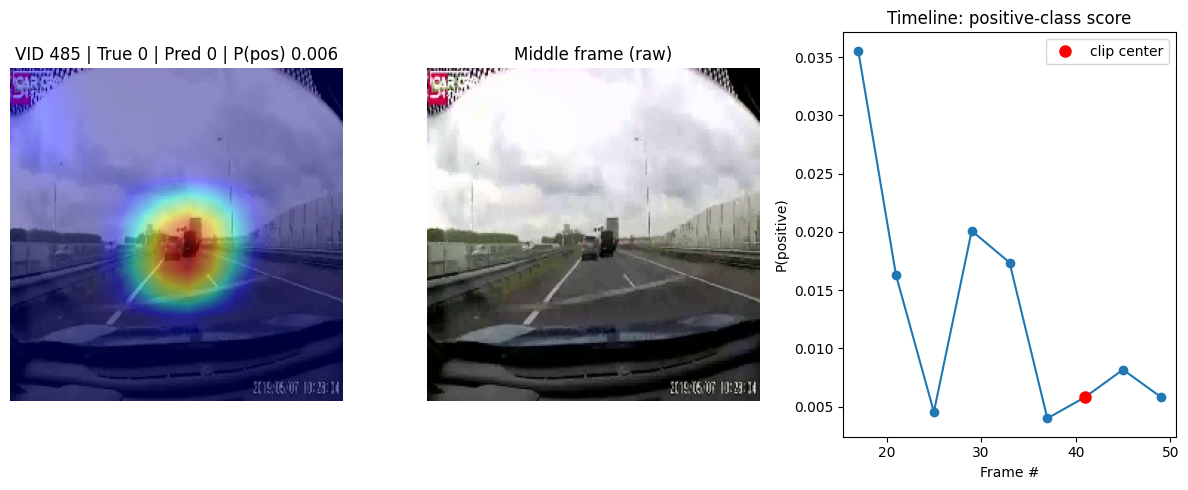

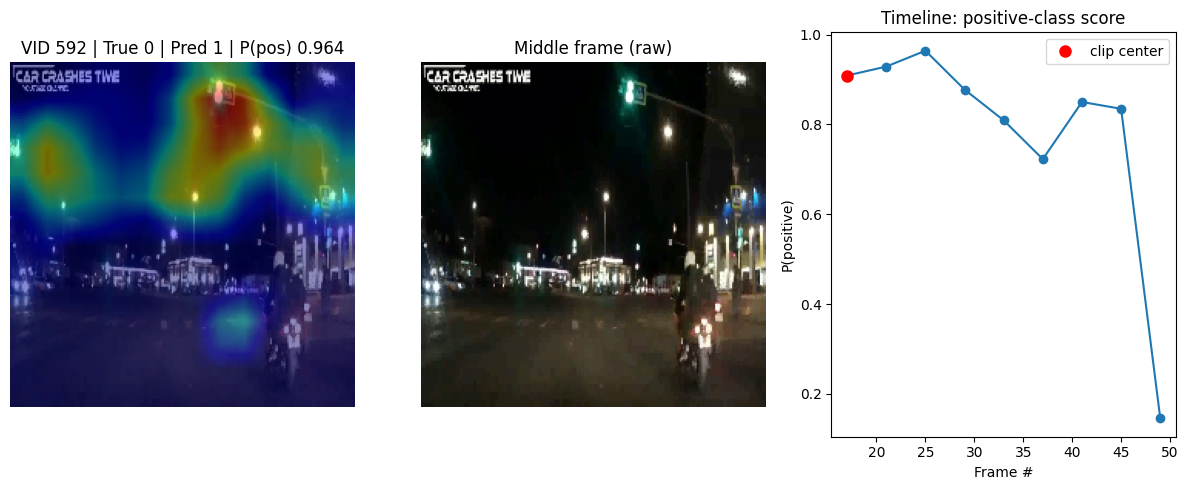

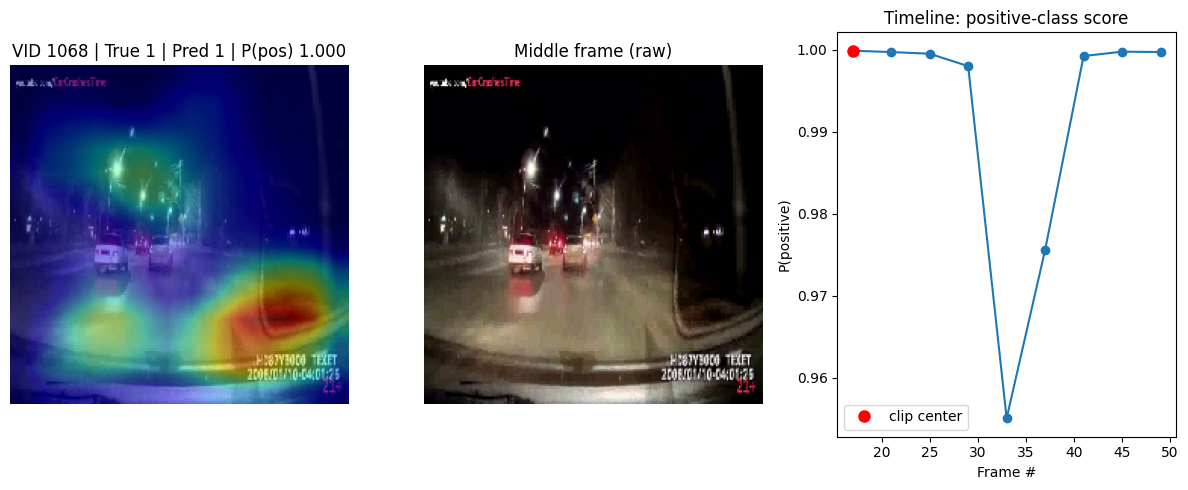

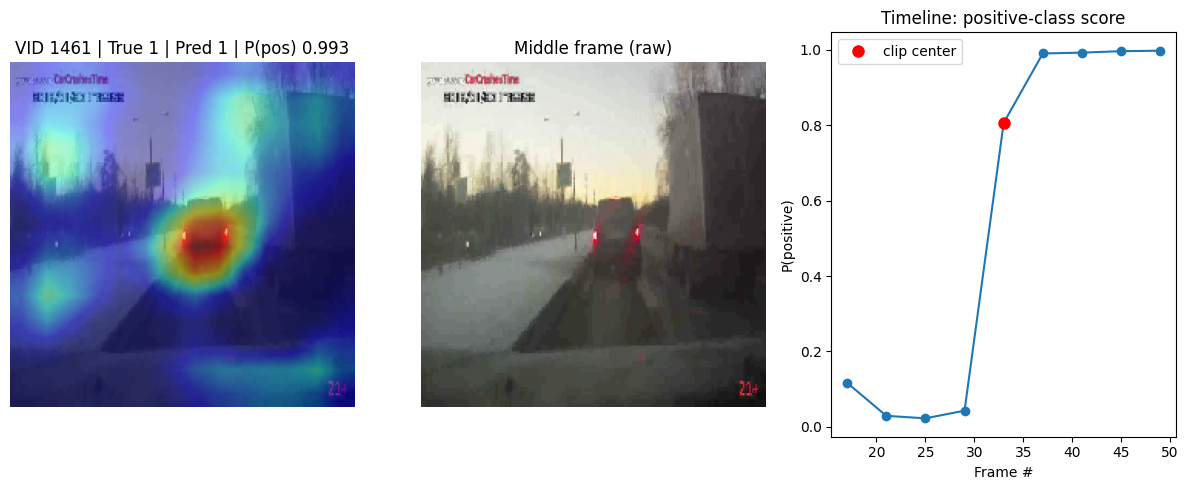

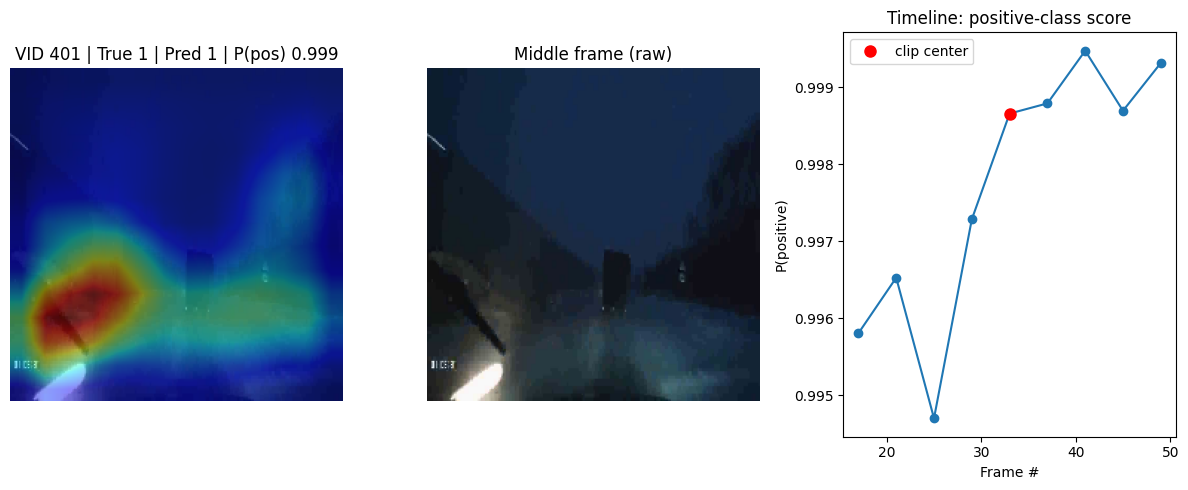

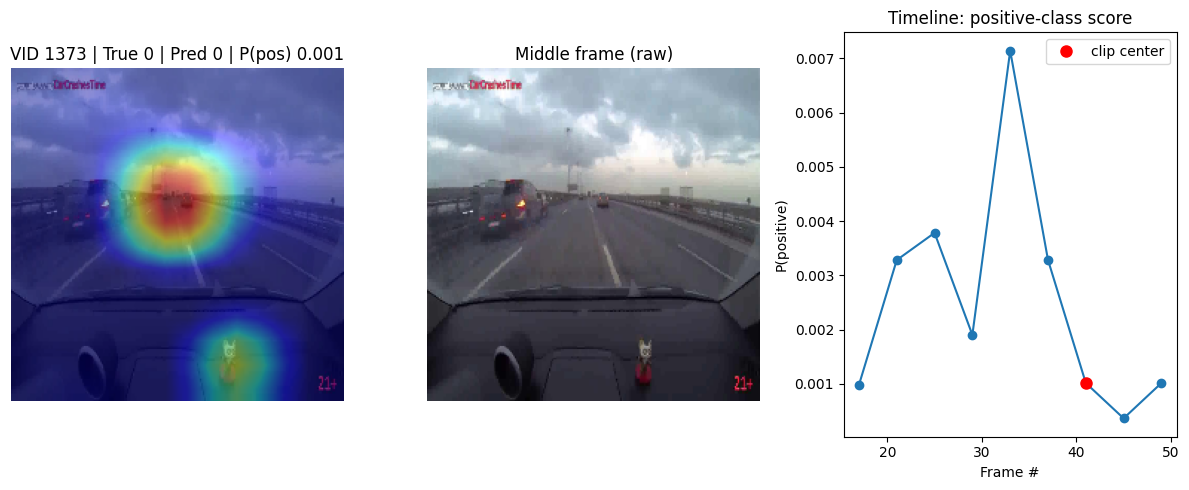

In [ ]:
# ============================
# Visualizations for Team A
# - Grad-CAM style heatmaps (RGB stream)
# - Timeline of decision scores across a clip (confidence vs frame index)
# - Example images showing AI predictions + heatmaps
# Usage: run after training; relies on `model`, `test_seqs`, `RESIZED_DIR`, load_image_tensor()
# ============================
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import torch.nn.functional as F
import numpy as np
import cv2
from pathlib import Path

device = DEVICE if 'DEVICE' in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# --- 1) Grad-CAM for 3D conv backbone (r3d_18)
# We'll hook a target convolutional layer in rgb_net (layer4) to get activations and gradients.

def get_last_conv_module(net):
    # Try to get a good final conv module from r3d_18
    # We prefer layer4[-1].conv2 or layer4[-1].conv1 depending on architecture
    try:
        mod = net.layer4[-1].conv2
    except:
        try:
            mod = net.layer4[-1].conv1
        except:
            # fallback: use last conv module by scanning
            mod = None
            for name, m in reversed(list(net.named_modules())):
                if isinstance(m, torch.nn.Conv3d):
                    mod = m
                    break
    return mod

# Grad-CAM utility
class GradCAM3D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        # register hooks
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inp, outp):
            # outp shape: (B, C, T', H', W')
            self.activations = outp.detach()
        def backward_hook(module, grad_in, grad_out):
            # grad_out[0] shape: same as outp
            self.gradients = grad_out[0].detach()
        self.fh = self.target_layer.register_forward_hook(forward_hook)
        self.bh = self.target_layer.register_backward_hook(backward_hook)

    def remove_hooks(self):
        self.fh.remove()
        self.bh.remove()

    def __call__(self, input_rgb_clip, target_class=None):
        """
        input_rgb_clip: tensor (1, C, T, H, W), normalized already
        target_class: int or None -> if None use predicted class
        Returns: heatmap (H, W) upsampled to input H,W ; score vector (logits) ; softmax prob for target class
        """
        self.model.zero_grad()
        # forward through full model but we need to pass both rgb & flow - for grad-cam we'll pass flow as zeros
        # Build dummy flow of same shape
        B, C, T, H, W = input_rgb_clip.shape
        dummy_flow = torch.zeros_like(input_rgb_clip).to(input_rgb_clip.device)
        input_rgb_clip = input_rgb_clip.to(input_rgb_clip.device)
        outputs = self.model(input_rgb_clip, dummy_flow)  # B x num_classes
        probs = F.softmax(outputs, dim=1)
        pred_class = int(torch.argmax(probs, dim=1).cpu().numpy()[0])
        if target_class is None:
            target_class = pred_class
        # compute gradient of the target class score
        score = outputs[0, target_class]
        score.backward(retain_graph=True)
        # activations: shape (B, C, T', H', W')
        acts = self.activations[0]    # C, T', H', W'
        grads = self.gradients[0]     # C, T', H', W'
        # global average pooling of gradients over (T',H',W') to get weights per channel
        weights = torch.mean(grads, dim=(1,2,3))  # C
        # weighted combination of activations
        cam = torch.zeros(acts.shape[1:], dtype=torch.float32, device=acts.device)  # T', H', W'
        for i, w in enumerate(weights):
            cam += w * acts[i]
        # Average over time dimension to get a single 2D map (T' reduced)
        cam2d = torch.mean(cam, dim=0)  # H', W'
        cam2d = cam2d.cpu().numpy()
        # relu
        cam2d = np.maximum(0, cam2d)
        # normalize to 0-1
        if cam2d.max() > 0:
            cam2d = cam2d - cam2d.min()
            cam2d = cam2d / (cam2d.max() + 1e-8)
        # upsample to input resolution (H,W)
        cam_upsampled = cv2.resize(cam2d, (W, H))
        # cleanup gradients
        self.model.zero_grad()
        return cam_upsampled, outputs.detach().cpu().numpy()[0], probs.detach().cpu().numpy()[0], pred_class

# find target conv module from rgb_net
target_layer = get_last_conv_module(model.rgb_net)
if target_layer is None:
    raise RuntimeError("Could not find a Conv3d target layer in rgb_net. Inspect model structure.")
gradcam = GradCAM3D(model, target_layer)

# Helper to overlay heatmap on an image
def overlay_heatmap_on_image(img_rgb, heatmap, alpha=0.5, colormap='jet'):
    """
    img_rgb: HxWx3 (uint8 or float 0..1)
    heatmap: HxW float 0..1
    returns overlayed image (uint8)
    """
    if img_rgb.dtype == np.float32 or img_rgb.dtype == np.float64:
        vis_img = (img_rgb * 255).astype(np.uint8).copy()
    else:
        vis_img = img_rgb.copy()
    cmap = cm.get_cmap(colormap)
    heatmap_colored = (cmap(heatmap)[:,:,:3] * 255).astype(np.uint8)
    overlay = cv2.addWeighted(vis_img, 1 - alpha, heatmap_colored, alpha, 0)
    return overlay

# --- 2) Timeline: compute model's softmax(positive class) across sliding windows across a single longer sequence
def compute_timeline_scores_for_video(clip_paths, window_len=SEQ_LEN, step=1, batch_size=8):
    """
    Given a list of resized frame paths (full video or clip), compute sliding-window scores for the positive class.
    Returns:
      centers: frame indices (center of each window)
      scores: positive-class probability for each window
    """
    model.eval()
    windows = []
    centers = []
    for start in range(0, len(clip_paths) - window_len + 1, step):
        window = clip_paths[start:start+window_len]
        centers.append(start + window_len//2)
        # load tensors for rgb stream
        rgb_list = []
        for p in window:
            rp = os.path.join(RESIZED_DIR, Path(p).name)
            img = cv2.imread(rp)[:,:,::-1]
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img.astype('float32') / 255.0
            # normalize using ImageNet mean/std
            img = (img - np.array([0.485,0.456,0.406])) / np.array([0.229,0.224,0.225])
            t = torch.from_numpy(img).permute(2,0,1).float()
            rgb_list.append(t)
        rgb = torch.stack(rgb_list, dim=1).unsqueeze(0).to(device)  # 1,C,T,H,W
        # dummy flow zeros (we only want RGB score timeline)
        flow = torch.zeros_like(rgb).to(device)
        windows.append((rgb, flow))
    scores = []
    # batch the windows to speed up
    for i in range(0, len(windows), batch_size):
        batch = windows[i:i+batch_size]
        rb = torch.cat([b[0] for b in batch], dim=0).to(device)
        fb = torch.cat([b[1] for b in batch], dim=0).to(device)
        with torch.no_grad():
            logits = model(rb, fb)
            probs = F.softmax(logits, dim=1)[:,1].cpu().numpy()  # positive-class prob
        scores.extend(probs.tolist())
    return centers, scores

# --- 3) Example visualization function that runs Grad-CAM on a single sequence and plots:
#    - Middle frame with overlayed heatmap
#    - Timeline of model confidence across sliding windows within the same video (if available)
#    - Show predicted label and confidence
def visualize_sequence_with_cam(sequence, show_timeline=True, save_path=None):
    """
    sequence: (clip_paths, label, vid) where clip_paths are original filenames (not resized)
    """
    clip_paths, label, vid = sequence
    # build resized paths for clip
    resized_paths = [os.path.join(RESIZED_DIR, Path(p).name) for p in clip_paths]
    # build rgb_tensor for the whole clip (1,C,T,H,W)
    rgb_list = []
    for rp in resized_paths:
        img = cv2.imread(rp)[:,:,::-1]
        img = img.astype('float32') / 255.0
        img = (img - np.array([0.485,0.456,0.406])) / np.array([0.229,0.224,0.225])
        t = torch.from_numpy(img).permute(2,0,1).float()
        rgb_list.append(t)
    rgb_clip = torch.stack(rgb_list, dim=1).unsqueeze(0).to(device)
    # compute grad-cam heatmap & model outputs
    cam_map, logits, probs, pred = gradcam(rgb_clip, target_class=None)
    pos_prob = float(probs[1])
    pred_class = int(pred)
    # middle original frame for display (use original raw frame if available)
    mid_idx = len(clip_paths)//2
    mid_raw = clip_paths[mid_idx]
    mid_img = cv2.imread(mid_raw)[:,:,::-1]
    mid_img = cv2.resize(mid_img, (IMG_SIZE, IMG_SIZE))
    overlay = overlay_heatmap_on_image(mid_img, cam_map, alpha=0.45)
    # plot
    plt.figure(figsize=(12,5))
    plt.subplot(1,3,1)
    plt.imshow(overlay)
    plt.title(f"VID {vid} | True {label} | Pred {pred_class} | P(pos) {pos_prob:.3f}")
    plt.axis('off')
    # raw middle frame
    plt.subplot(1,3,2)
    plt.imshow(mid_img)
    plt.title("Middle frame (raw)")
    plt.axis('off')
    # timeline (compute if requested): we need a longer sequence (we can use the video_frames mapping to get entire video resized list)
    if show_timeline:
        # find resized list for this vid from video_frames dict used earlier; fallback to clip
        try:
            full_video_list = video_frames[vid]  # original paths list
            # compute sliding windows across full video (use resized names)
            centers, scores = compute_timeline_scores_for_video(full_video_list, window_len=SEQ_LEN, step=max(1, SEQ_LEN//4))
            # convert centers from index into actual frame numbers (using parsed frame numbers)
            frame_nums = []
            for start in centers:
                # center corresponds to index in full_video_list
                # get underlying filename and parse frame number
                pth = full_video_list[start + SEQ_LEN//2] if (start + SEQ_LEN//2) < len(full_video_list) else full_video_list[min(start, len(full_video_list)-1)]
                vid_tmp, fno_tmp = parse_vid_frame(pth)
                frame_nums.append(fno_tmp if fno_tmp is not None else start)
            plt.subplot(1,3,3)
            plt.plot(frame_nums, scores, '-o')
            plt.xlabel("Frame #"); plt.ylabel("P(positive)"); plt.title("Timeline: positive-class score")
            # highlight center point
            try:
                # find center frame number of our clip
                center_frame_path = clip_paths[mid_idx]
                _, center_frame_no = parse_vid_frame(center_frame_path)
                if center_frame_no is not None:
                    # find closest index in frame_nums
                    idx_closest = np.argmin([abs(fn - center_frame_no) for fn in frame_nums])
                    plt.plot(frame_nums[idx_closest], scores[idx_closest], 'ro', markersize=8, label='clip center')
                    plt.legend()
            except Exception:
                pass
        except Exception:
            # fallback plot: per-frame logits in clip
            plt.subplot(1,3,3)
            with torch.no_grad():
                logits_clip = model(rgb_clip.to(device), torch.zeros_like(rgb_clip).to(device))
                ps = F.softmax(logits_clip, dim=1)[0,:,1].cpu().numpy() if logits_clip.shape[0] == 1 else F.softmax(logits_clip, dim=1)[:,1].cpu().numpy()
                plt.plot(range(len(ps)), ps, '-o'); plt.xlabel("Frame index (window center)"); plt.title("Clip-level pos-prob")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
    plt.show()

# === USAGE: Visualize N random sequences from test set ===
n_show = 6
random.seed(0)
sample_indices = random.sample(range(len(test_seqs)), k=min(n_show, len(test_seqs)))
for idx in sample_indices:
    seq = test_seqs[idx]
    visualize_sequence_with_cam(seq, show_timeline=True, save_path=None)

# === OPTIONAL: create a grid of top examples by confidence ===
# compute confidence for all test sequences then show top-k confident correct and incorrect
def compute_confidences_for_sequences(seqs, batch_size=8):
    confidences = []
    model.eval()
    for i in range(0, len(seqs), batch_size):
        batch = seqs[i:i+batch_size]
        # prepare tensors
        rgb_batch = []
        flow_batch = []
        for clip, label, vid in batch:
            resized = [os.path.join(RESIZED_DIR, Path(p).name) for p in clip]
            # build rgb tensor
            imgs = []
            for rp in resized:
                img = cv2.imread(rp)[:,:,::-1]
                img = img.astype('float32')/255.0
                img = (img - np.array([0.485,0.456,0.406])) / np.array([0.229,0.224,0.225])
                imgs.append(torch.from_numpy(img).permute(2,0,1).float())
            rgb_batch.append(torch.stack(imgs, dim=1))
            # flow zeros (we only care about rgb confidence ordering)
            flow_batch.append(torch.zeros_like(rgb_batch[-1]))
        rb = torch.stack(rgb_batch, dim=0).to(device)
        fb = torch.stack(flow_batch, dim=0).to(device)
        with torch.no_grad():
            logits = model(rb, fb)
            probs = F.softmax(logits, dim=1)[:,1].cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()
        for j, (clip, label, vid) in enumerate(batch):
            confidences.append((probs[j], int(preds[j]), int(label), clip, vid))
    return confidences

# compute and display top-K confident correct and incorrect sequences
conf_list = compute_confidences_for_sequences(test_seqs, batch_size=8)
# sort by confidence descending
conf_sorted = sorted(conf_list, key=lambda x: x[0], reverse=True)
topk = 6
print("Top confident predictions (showing top-k):")
for i in range(topk):
    prob, pred, true, clip, vid = conf_sorted[i]
    print(f"{i+1}. VID={vid} pred={pred} true={true} prob={prob:.4f}")
    visualize_sequence_with_cam((clip, true, vid), show_timeline=False)

# Clean up gradcam hooks
gradcam.remove_hooks()
